# NB1 — The input & the audience  ·  *Act 1*

**Question:** what data do we have, can we trust it, and who is SAMI reaching?

SAMI is a WhatsApp chatbot for migrants in Colombia. This notebook establishes the
evidentiary base for everything that follows: it profiles the two data sources, states
their limits plainly, and draws the audience portrait — one variable at a time, no
cross-cuts (those belong to NB2).

*Reproducibility:* every number traces to the reconciliation table (printed at the top
**and** bottom of this notebook — the two must match). All cleaning lives in `src/sami/`;
this notebook only consumes it. No raw phone number renders anywhere (PII gate).

In [1]:
import sys; sys.path.insert(0, "../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sami import load_sami, theme, canon, geo, qa

WINDOW = None  # filled after load; every subtitle carries metric + n + window

def titled(ax, title, subtitle, source="Source: SAMI bot responses log."):
    # Assertion-evidence title (the finding), then subtitle (metric + n + window),
    # then source. Title sits well above the axes (pad) so the subtitle, placed
    # just above the axes top, never collides with it.
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="semibold", color=theme.INK, pad=30)
    ax.annotate(subtitle, xy=(0, 1.0), xycoords="axes fraction", xytext=(0, 8),
                textcoords="offset points", fontsize=9.5, color=theme.INK2, va="bottom")
    ax.annotate(source, xy=(0, 0), xycoords="axes fraction", xytext=(0, -42),
                textcoords="offset points", fontsize=8, color=theme.MUTED, va="top")


def titled_map(fig, ax, title, subtitle, source):
    # Full-bleed maps (axis off) have no data margin, so stack the title block at
    # FIGURE coordinates above the map and reserve headroom via subplots_adjust.
    fig.subplots_adjust(top=0.86, bottom=0.08, left=0.02, right=0.98)
    fig.text(0.02, 0.965, title, fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
    fig.text(0.02, 0.915, subtitle, fontsize=9.5, color=theme.INK2, ha="left", va="top")
    fig.text(0.02, 0.015, source, fontsize=8, color=theme.MUTED, ha="left", va="bottom")

d = load_sami()
r = d.responses
m = d.meal
msgs = d.messages
WINDOW = f"{pd.to_datetime(d.run_meta['ts_min']).date()} – {pd.to_datetime(d.run_meta['ts_max']).date()}"

# user-level profile frame (one row per user; 26 users have 2-3 records)
users = r.sort_values("ts").drop_duplicates("user_id", keep="first").reset_index(drop=True)
N_USERS = users["user_id"].nunique()
print("Analysis window:", WINDOW, "| users:", N_USERS, "| records:", len(r), "| messages:", len(msgs))

Analysis window: 2026-03-25 – 2026-07-03 | users: 917 | records: 946 | messages: 2991


## Reconciliation table (P10) — the run's identity card
Every figure's *n* traces here. The identical table is reprinted at the close.

In [2]:
recon = d.reconciliation
print(f"Export: {d.run_meta['responses_file']}  +  {d.run_meta['meal_file']}")
print(f"Window: {WINDOW}   Rows(responses/meal): {d.run_meta['responses_rows']}/{d.run_meta['meal_rows']}\n")
display(recon)
# PII gate: zero whatsapp:/phone runs in any frame we will render from
assert all(len(qa.pii_scan(f)) == 0 for f in (r, msgs, m)), "PII gate failed"
print("PII gate: clean (no whatsapp:/7+-digit runs in responses, messages, meal).")

Export: MMC_bot_responses_1783087815.xlsx  +  MMC_MEAL_1783087939.xlsx
Window: 2026-03-25 – 2026-07-03   Rows(responses/meal): 948/78



,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


PII gate: clean (no whatsapp:/7+-digit runs in responses, messages, meal).

## 1 · Sources & reliability

Two sources feed the analysis: the **bot responses log** (every user who completed the
intake form) and the **MEAL survey** (a voluntary satisfaction follow-up). Their
completeness and reach set the ceiling on what we can claim.

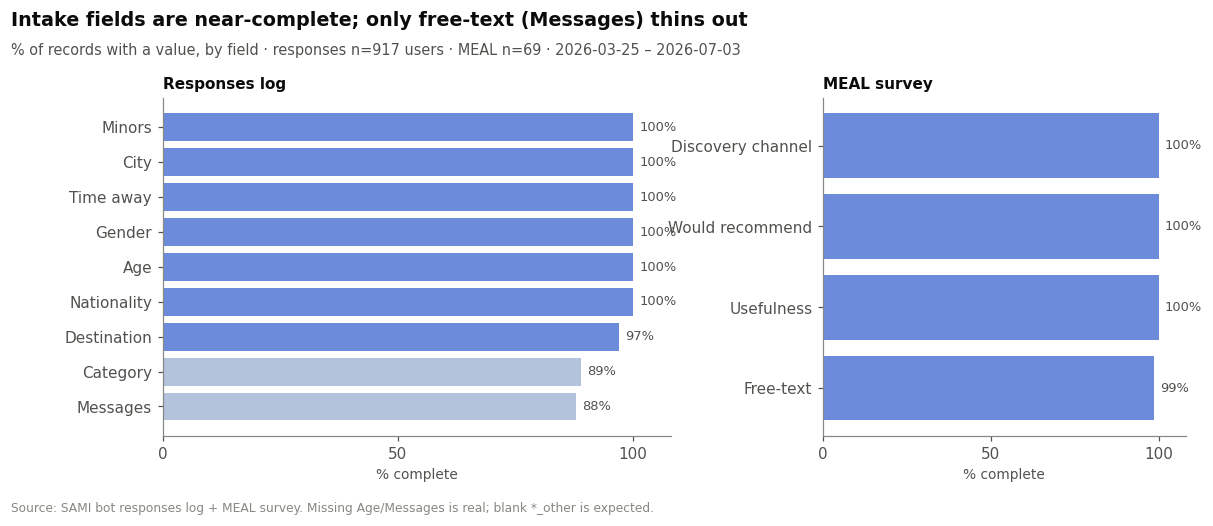

In [3]:
# Figure 1 — field completeness per source (two panels)
resp_fields = {
    "Nationality": "nationality_clean", "City": "city_clean", "Gender": "gender_clean",
    "Age": "age_num", "Minors": "Minors", "Time away": "Away_duration",
    "Destination": "Destination_Country", "Messages": "Messages", "Category": "Chat_summary",
}
def pct_complete(df, col):
    s = df[col].astype("string").str.strip()
    return 100 * s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA}).notna().mean()

resp_c = pd.Series({k: pct_complete(users, v) for k, v in resp_fields.items()}).sort_values()
meal_fields = {"Usefulness": "usefulness_rating", "Would recommend": "would_recommend",
               "Free-text": "recommendation_text", "Discovery channel": "discovery_channel"}
meal_c = pd.Series({k: pct_complete(m, v) for k, v in meal_fields.items()}).sort_values()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
for ax, s, lab in [(a1, resp_c, "Responses log"), (a2, meal_c, "MEAL survey")]:
    cols = [theme.PRIMARY if v >= 90 else (theme.AGUA_MID if v >= 60 else theme.MADERA) for v in s]
    ax.barh(s.index, s.values, color=cols)
    for y, v in enumerate(s.values):
        ax.annotate(f"{v:.0f}%", (v, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=theme.INK2)
    ax.set_xlim(0, 108); ax.set_xticks([0, 50, 100]); ax.set_xlabel("% complete", fontsize=9)
    ax.set_title(lab, loc="left", fontsize=10, fontweight="semibold", color=theme.INK, pad=6)
fig.subplots_adjust(top=0.80, bottom=0.16, wspace=0.35)
fig.text(0.01, 0.965, "Intake fields are near-complete; only free-text (Messages) thins out",
         fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
fig.text(0.01, 0.905, f"% of records with a value, by field · responses n={N_USERS} users · MEAL n={len(m)} · {WINDOW}",
         fontsize=9.5, color=theme.INK2, ha="left", va="top")
fig.text(0.01, 0.01, "Source: SAMI bot responses log + MEAL survey. Missing Age/Messages is real; blank *_other is expected.",
         fontsize=8, color=theme.MUTED, ha="left", va="bottom")
plt.show()

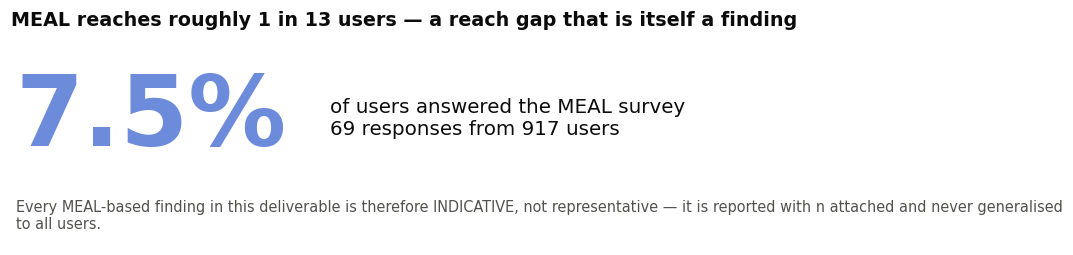

In [4]:
# Figure 2 — MEAL response-rate big-number callout (not a chart)
rate = 100 * len(m) / N_USERS
fig, ax = plt.subplots(figsize=(11, 2.4)); ax.axis("off")
ax.text(0.005, 0.62, f"{rate:.1f}%", fontsize=64, fontweight="bold", color=theme.PRIMARY,
        va="center", ha="left", transform=ax.transAxes)
ax.text(0.34, 0.62, f"of users answered the MEAL survey\n{len(m)} responses from {N_USERS} users",
        fontsize=13, color=theme.INK, va="center", ha="left", transform=ax.transAxes)
ax.text(0.005, 0.06,
        "Every MEAL-based finding in this deliverable is therefore INDICATIVE, not representative "
        "— it is reported with n attached and never generalised to all users.",
        fontsize=9.5, color=theme.INK2, va="bottom", ha="left", transform=ax.transAxes, wrap=True)
ax.set_title("MEAL reaches roughly 1 in 13 users — a reach gap that is itself a finding",
             loc="left", fontsize=12.5, fontweight="semibold", color=theme.INK, pad=10)
plt.show()

## 2 · Audience profile

Who is SAMI actually reaching? Four single-variable cuts — gender, age, care
responsibilities and geography. The headline emerges by the end of the section: this is a
**settled**, working-age, overwhelmingly Venezuelan population concentrated in a handful
of cities — an audience for *integration* support, not route information.

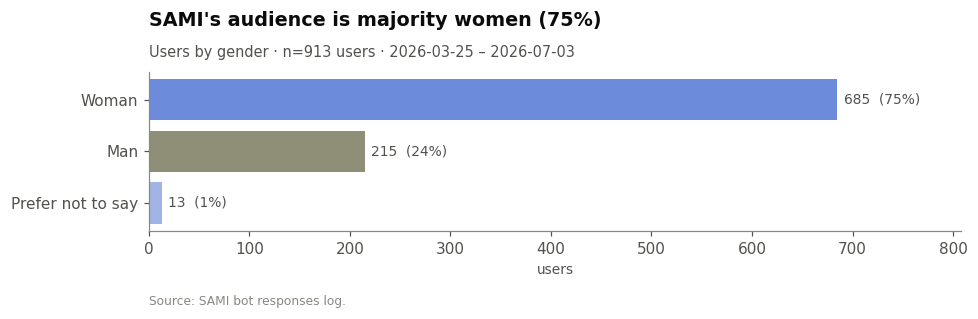

In [5]:
# Figure 3 — gender (plain horizontal bar; replaces the old radial chart)
g = users["gender_clean"].map(lambda x: canon.GENDER_DISPLAY.get(x, x)).value_counts()
g = g.reindex(["Woman", "Man", "Prefer not to say", "Other"]).dropna()
share = 100 * g / g.sum()
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.barh(g.index[::-1], g.values[::-1], color=theme.cat_colors(len(g))[::-1])
for y, (n, p) in enumerate(zip(g.values[::-1], share.values[::-1])):
    ax.annotate(f"{int(n)}  ({p:.0f}%)", (n, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=theme.INK2)
ax.set_xlim(0, g.max() * 1.18); ax.set_xlabel("users", fontsize=9)
titled(ax, f"SAMI's audience is majority women ({share.iloc[0]:.0f}%)",
       f"Users by gender · n={int(g.sum())} users · {WINDOW}")
plt.tight_layout(); plt.show()

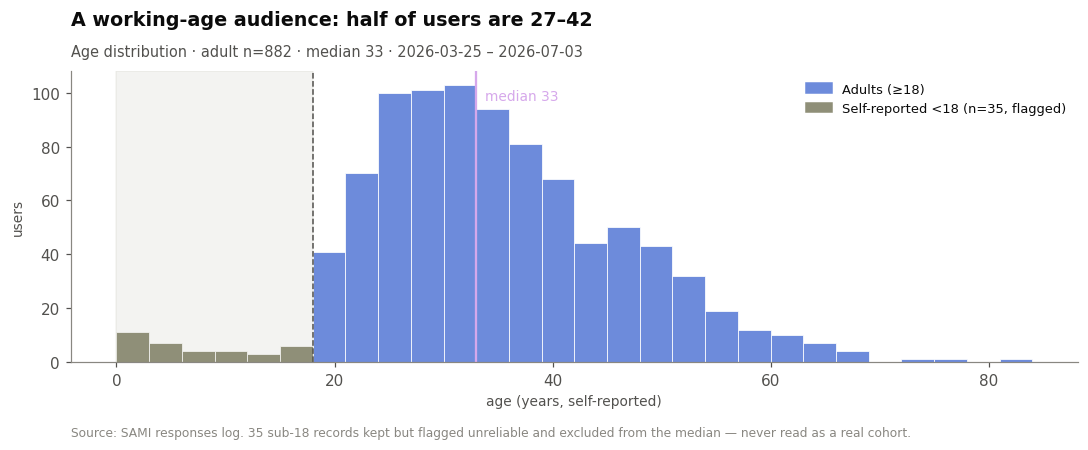

In [6]:
# Figure 4 — age distribution with sub-18 flagged band + honesty note
age = users["age_num"].dropna()
adult = age[age >= 18]
fig, ax = plt.subplots(figsize=(10, 4.2))
bins = np.arange(0, max(70, age.max()) + 5, 3)
ax.hist(adult, bins=bins, color=theme.PRIMARY, edgecolor="white", linewidth=0.5)
ax.hist(age[age < 18], bins=bins, color=theme.MADERA, edgecolor="white", linewidth=0.5)
ax.axvline(18, color=theme.INK2, lw=1, ls="--")
ax.axvspan(0, 18, color=theme.MADERA, alpha=0.10)
med = adult.median()
ax.axvline(med, color=theme.AMEBA, lw=1.5)
ax.annotate(f"median {med:.0f}", (med, ax.get_ylim()[1] * 0.9), xytext=(6, 0),
            textcoords="offset points", color=theme.AMEBA, fontsize=9)
ax.legend(handles=[Patch(color=theme.PRIMARY, label="Adults (≥18)"),
                   Patch(color=theme.MADERA, label=f"Self-reported <18 (n={int((age<18).sum())}, flagged)")],
          loc="upper right", frameon=False, fontsize=8.5)
ax.set_xlabel("age (years, self-reported)", fontsize=9); ax.set_ylabel("users", fontsize=9)
p26, p41 = np.percentile(adult, [25, 75])
titled(ax, f"A working-age audience: half of users are {p26:.0f}–{p41:.0f}",
       f"Age distribution · adult n={len(adult)} · median {med:.0f} · {WINDOW}",
       source=f"Source: SAMI responses log. {int((age<18).sum())} sub-18 records kept but flagged unreliable "
              "and excluded from the median — never read as a real cohort.")
plt.tight_layout(); plt.show()

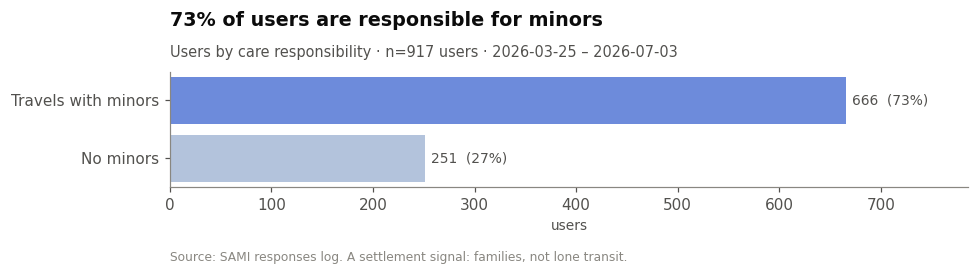

In [7]:
# Figure 5 — care responsibilities (one bar; Minors Si/No)
care = users["Minors"].map({"Si": "Travels with minors", "No": "No minors"}).value_counts()
care = care.reindex(["Travels with minors", "No minors"]).dropna()
share = 100 * care / care.sum()
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.barh(care.index[::-1], care.values[::-1], color=[theme.AGUA_MID, theme.PRIMARY])
for y, (n, p) in enumerate(zip(care.values[::-1], share.values[::-1])):
    ax.annotate(f"{int(n)}  ({p:.0f}%)", (n, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=theme.INK2)
ax.set_xlim(0, care.max() * 1.18); ax.set_xlabel("users", fontsize=9)
titled(ax, f"{share.iloc[0]:.0f}% of users are responsible for minors",
       f"Users by care responsibility · n={int(care.sum())} users · {WINDOW}",
       source="Source: SAMI responses log. A settlement signal: families, not lone transit.")
plt.tight_layout(); plt.show()

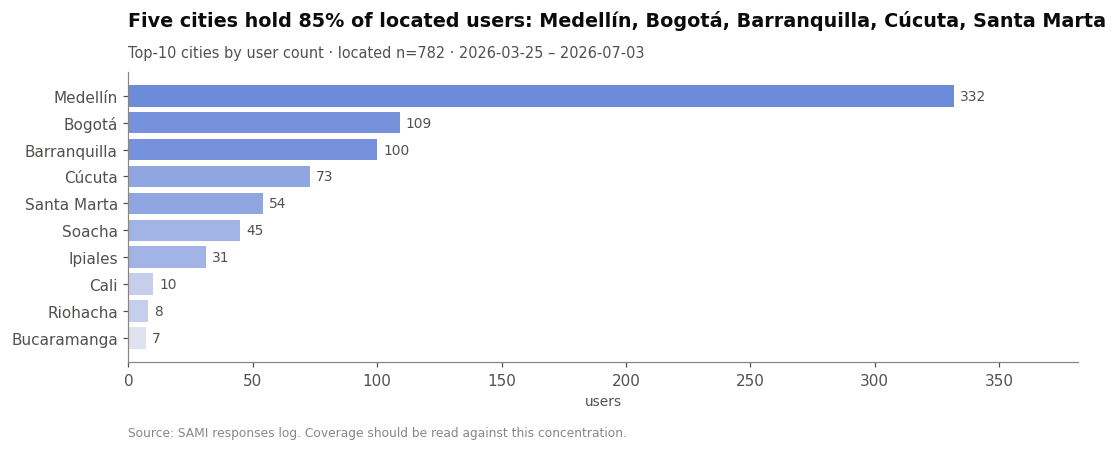

In [8]:
# Figure 6 — city top-10 bar
city = users.loc[users["city_canon"] != "Otra", "city_canon"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(city.index[::-1], city.values[::-1], color=theme.seq_colors(len(city)))
for y, n in enumerate(city.values[::-1]):
    ax.annotate(f"{n}", (n, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=theme.INK2)
top5 = 100 * city.head(5).sum() / (users["city_canon"] != "Otra").sum()
ax.set_xlim(0, city.max() * 1.15); ax.set_xlabel("users", fontsize=9)
titled(ax, f"Five cities hold {top5:.0f}% of located users: {', '.join(city.head(5).index)}",
       f"Top-10 cities by user count · located n={(users['city_canon']!='Otra').sum()} · {WINDOW}",
       source="Source: SAMI responses log. Coverage should be read against this concentration.")
plt.tight_layout(); plt.show()

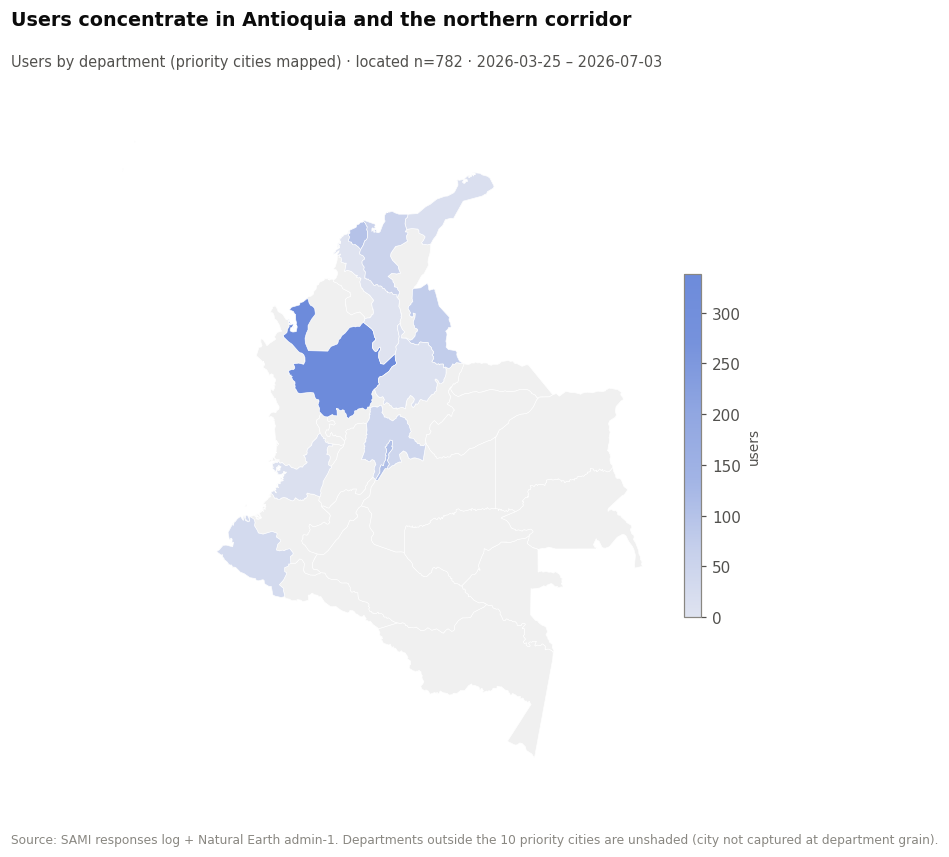

In [9]:
# Figure 7 — department choropleth (users per department)
dept_counts = users["department"].value_counts()
fig, ax = plt.subplots(figsize=(7.5, 8))
sm = geo.dept_choropleth(ax, dept_counts)
cb = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.02); cb.set_label("users", fontsize=9)
top_dept = dept_counts.index[0]
titled_map(fig, ax, f"Users concentrate in {top_dept} and the northern corridor",
           f"Users by department (priority cities mapped) · located n={int(dept_counts.sum())} · {WINDOW}",
           "Source: SAMI responses log + Natural Earth admin-1. Departments outside the 10 priority "
           "cities are unshaded (city not captured at department grain).")
plt.show()

## 3 · Migration journey

How long have they been away, and where are they heading? Together these reframe SAMI's
mandate from *transit* to *settlement*.

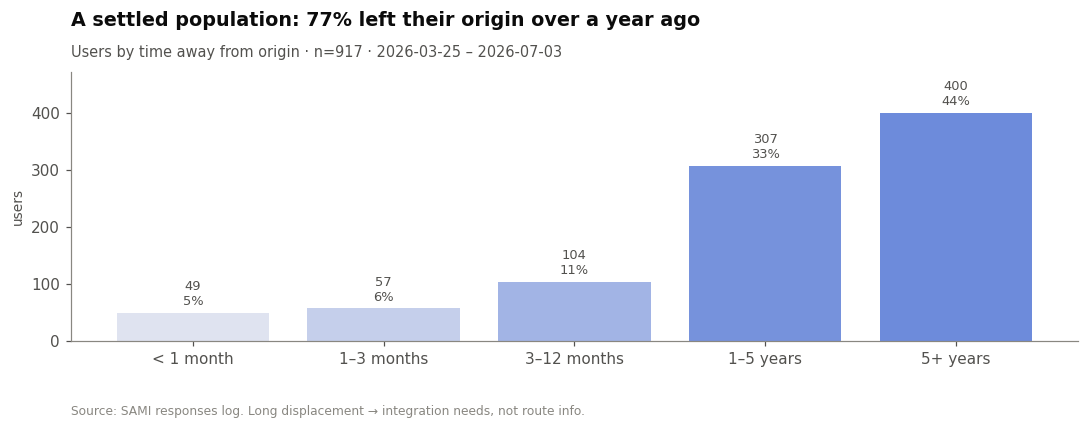

In [10]:
# Figure 8 — time-away distribution (ordered)
aw = users["away_duration_canon"].dropna()
order = [x for x in canon.AWAY_DURATION_ORDER if x in aw.unique()]
counts = aw.value_counts().reindex(order)
labels = [canon.AWAY_DURATION_DISPLAY_EN[x] for x in order]
share = 100 * counts / counts.sum()
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.bar(labels, counts.values, color=theme.seq_colors(len(counts)))
for x, (n, p) in enumerate(zip(counts.values, share.values)):
    ax.annotate(f"{n}\n{p:.0f}%", (x, n), xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.5, color=theme.INK2)
ax.set_ylim(0, counts.max() * 1.18); ax.set_ylabel("users", fontsize=9)
long = 100 * counts.reindex([x for x in order if x in
        ("Entre 1 a 5 años", "Hace más de 5 años")]).sum() / counts.sum()
titled(ax, f"A settled population: {long:.0f}% left their origin over a year ago",
       f"Users by time away from origin · n={int(counts.sum())} · {WINDOW}",
       source="Source: SAMI responses log. Long displacement → integration needs, not route info.")
plt.tight_layout(); plt.show()

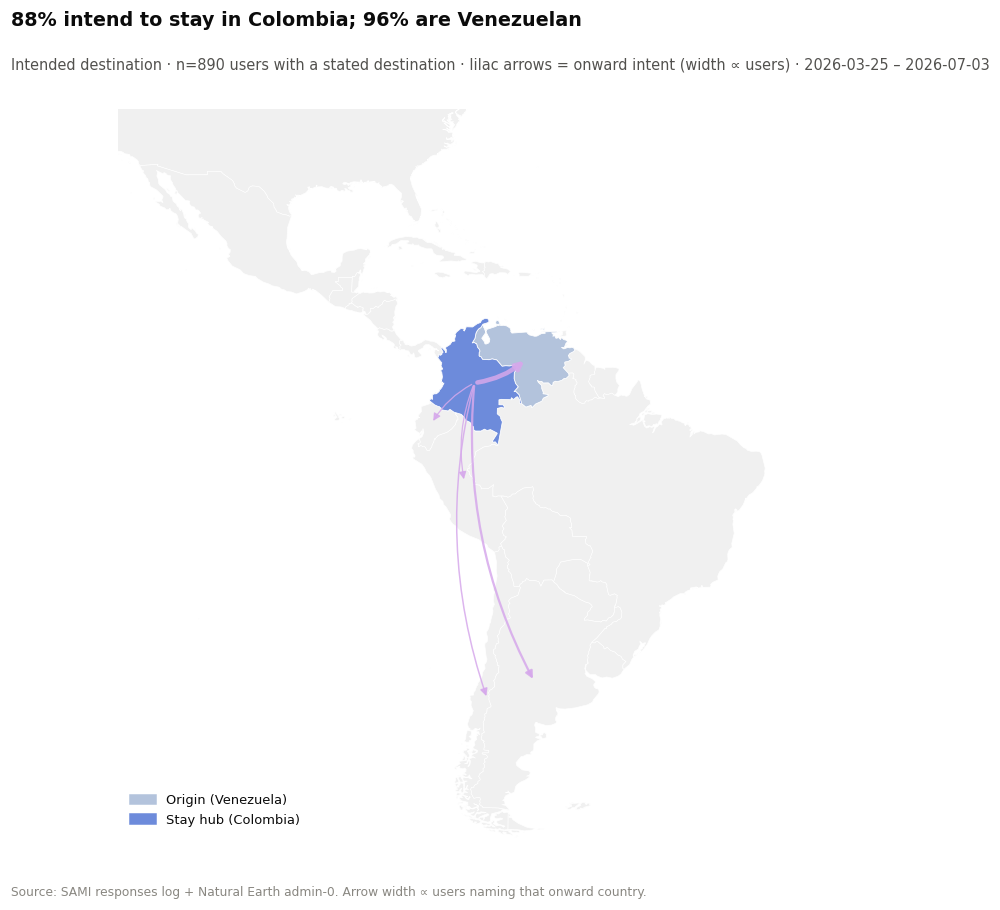

In [11]:
# Figure 9 — Americas migration flow map (origin fill / stay hub / onward arrows)
onward = users["Destination_Country"].value_counts().to_dict()   # non-null destinations
n_dest = int(sum(onward.values()))
stay = 100 * onward.get("Colombia", 0) / n_dest                  # % of stated destinations = Colombia
ve = 100 * (users["nationality_canon"] == "Venezuela").mean()
fig, ax = plt.subplots(figsize=(8.5, 8.5))
geo.americas_flow_map(ax, origin="Venezuela", hub="Colombia", onward=onward)
handles = [Patch(color=theme.AGUA_MID, label="Origin (Venezuela)"),
           Patch(color=theme.PRIMARY, label="Stay hub (Colombia)")]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8.5)
titled_map(fig, ax, f"{stay:.0f}% intend to stay in Colombia; {ve:.0f}% are Venezuelan",
           f"Intended destination · n={n_dest} users with a stated destination · lilac arrows = onward intent (width ∝ users) · {WINDOW}",
           "Source: SAMI responses log + Natural Earth admin-0. Arrow width ∝ users naming that onward country.")
plt.show()

## 4 · What we now know

In [12]:
lines = [
    f"1. Reach vs. representativeness: SAMI logged {N_USERS} users over {WINDOW}; "
    f"MEAL covers only {100*len(m)/N_USERS:.1f}% — every survey claim stays indicative.",
    f"2. Majority women ({100*(users['gender_clean']=='Mujer').mean():.0f}%), working-age "
    f"(median {users.loc[users['age_num']>=18,'age_num'].median():.0f}); "
    f"{100*(users['Minors']=='Si').mean():.0f}% responsible for minors → families, not lone transit.",
    f"3. Overwhelmingly Venezuelan ({100*(users['nationality_canon']=='Venezuela').mean():.0f}%) and settled: "
    f"{100*users['away_duration_canon'].isin(['Entre 1 a 5 años','Hace más de 5 años']).mean():.0f}% away 1+ years.",
    f"4. Geographically concentrated: five cities hold most located users; "
    f"{100*users['Destination_Country'].eq('Colombia').sum()/users['Destination_Country'].notna().sum():.0f}% "
    f"of users with a stated destination intend to stay in Colombia.",
    "5. Implication for programme design: this is an INTEGRATION audience "
    "(documentation, health, employment), not a route-information one.",
]
print("\n".join(lines))

1. Reach vs. representativeness: SAMI logged 917 users over 2026-03-25 – 2026-07-03; MEAL covers only 7.5% — every survey claim stays indicative.
2. Majority women (75%), working-age (median 33); 73% responsible for minors → families, not lone transit.
3. Overwhelmingly Venezuelan (96%) and settled: 77% away 1+ years.
4. Geographically concentrated: five cities hold most located users; 88% of users with a stated destination intend to stay in Colombia.
5. Implication for programme design: this is an INTEGRATION audience (documentation, health, employment), not a route-information one.


### Reconciliation table (P10) — bottom · must match the top

In [13]:
recon_bottom = qa.reconciliation_table(d.responses, d.messages, d.meal)
assert recon_bottom.equals(d.reconciliation), "Reconciliation drift between top and bottom!"
print("Reconciliation stable top-to-bottom ✓")
display(recon_bottom)

Reconciliation stable top-to-bottom ✓


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending
